# Import

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # just to make sure

# No 1 dan 5

In [ ]:
image_bgr = cv2.imread('wony.jpg')
b, g, r = cv2.split(image_bgr) # dipisahin channel warna nya dalam urutan BGR
gray = (0.299 * r) + (0.587 * g) + (0.114 * b) # penggunaan rumus Luminance

# No 2

In [ ]:
# informasi gambar sebelum dan sesudah di convert
h, w, c = image_bgr.shape

print(f"Bentuk Matriks (H, W, C): {image_bgr.shape}")
print(f"Resolusi Spasial (W x H): {w} x {h} pixel")
print(f"Total Pixel: {h * w} pixel")
print(f"Total Nilai (3 channel): {h * w * c}")
print(f"Tipe Data: {image_bgr.dtype}")
print(f"Nilai Min: {image_bgr.min()}, Max: {image_bgr.max()}")

Bentuk Matriks (H, W, C): (720, 1280, 3)
Resolusi Spasial (W x H): 1280 x 720 pixel
Total Pixel: 921600 pixel
Total Nilai (3 channel): 2764800
Tipe Data: uint8
Nilai Min: 3, Max: 255


In [ ]:
# 2. Slicing Channel RGB
img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

print(f"Rata-rata intensitas Channel R: {R.mean():.2f}")
print(f"Rata-rata intensitas Channel G: {G.mean():.2f}")
print(f"Rata-rata intensitas Channel B: {B.mean():.2f}")

Rata-rata intensitas Channel R: 90.52
Rata-rata intensitas Channel G: 81.83
Rata-rata intensitas Channel B: 81.82


# No 3

In [ ]:
def quantize(img, bits):
  levels = 2 ** bits
  step = 256 / levels
  return (np.floor(img / step) * (255 / (levels - 1))).astype(np.uint8)

In [ ]:
q8 = quantize(gray, 8)
q7 = quantize(gray, 7)
q6 = quantize(gray, 6)
q5 = quantize(gray, 5)
q4 = quantize(gray, 4)
q3 = quantize(gray, 3)
q2 = quantize(gray, 2)
q1 = quantize(gray, 1) # Biner

# No 4

In [ ]:
# 4. Simulasi Downsampling Spasial (Resolusi Spasial)
h, w = gray.shape

# versi dengan pre-filter (INTER_LINEAR merata-ratakan piksel = anti aliasing)
downsampled = cv2.resize(gray, (w // 8, h // 8), interpolation=cv2.INTER_LINEAR)
pixelated = cv2.resize(downsampled, (w, h), interpolation=cv2.INTER_NEAREST)

# versi tanpa pre-filter (piksel diambil langsung, tetangganya dibuang = aliasing)
downsampled_nn = cv2.resize(gray, (w // 8, h // 8), interpolation=cv2.INTER_NEAREST)
aliased = cv2.resize(downsampled_nn, (w, h), interpolation=cv2.INTER_NEAREST)

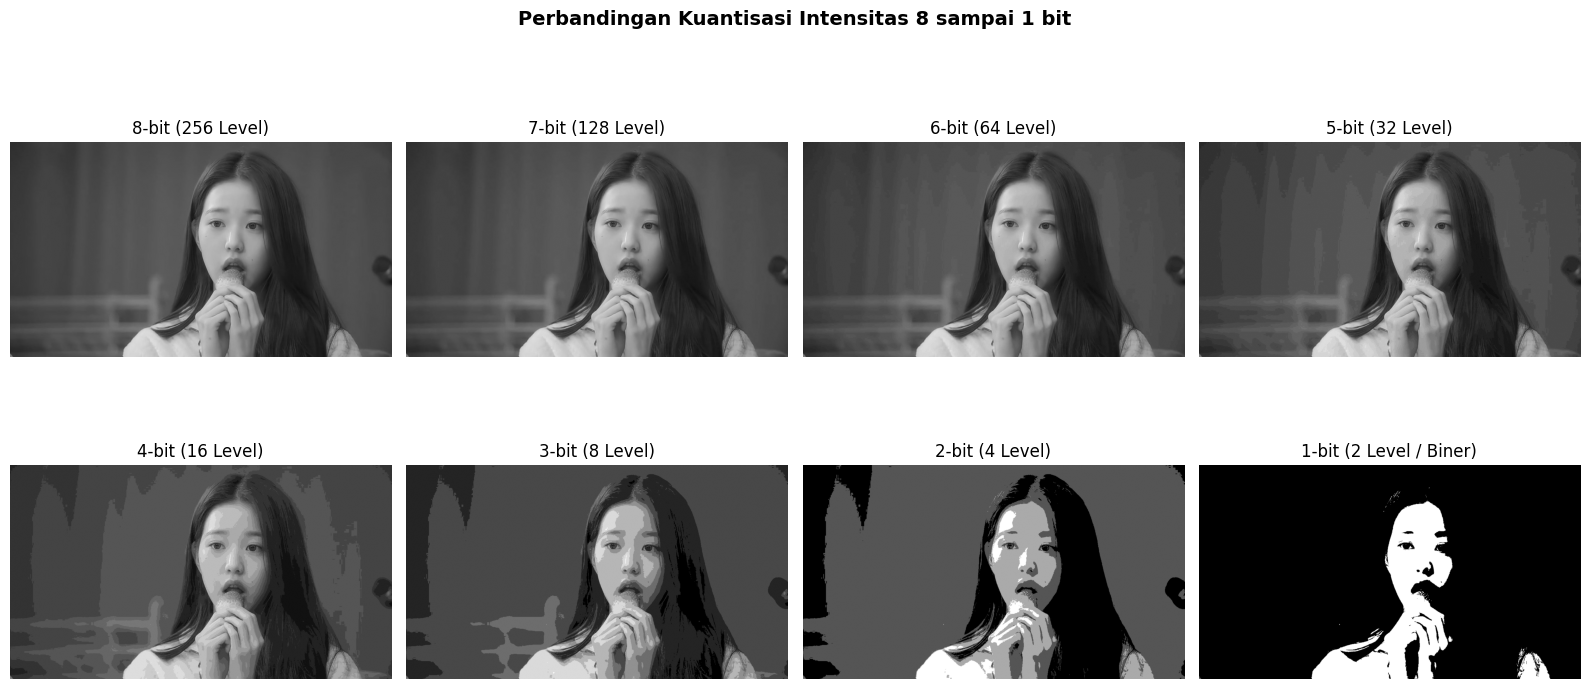

In [ ]:
# 3. Perbandingan Kuantisasi Intensitas 8 -> 1 bit
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Perbandingan Kuantisasi Intensitas 8 sampai 1 bit', fontsize=14, fontweight='bold')

axs[0, 0].imshow(q8, cmap='gray', vmin=0, vmax=255); axs[0, 0].set_title('8-bit (256 Level)')
axs[0, 1].imshow(q7, cmap='gray', vmin=0, vmax=255); axs[0, 1].set_title('7-bit (128 Level)')
axs[0, 2].imshow(q6, cmap='gray', vmin=0, vmax=255); axs[0, 2].set_title('6-bit (64 Level)')
axs[0, 3].imshow(q5, cmap='gray', vmin=0, vmax=255); axs[0, 3].set_title('5-bit (32 Level)')

axs[1, 0].imshow(q4, cmap='gray', vmin=0, vmax=255); axs[1, 0].set_title('4-bit (16 Level)')
axs[1, 1].imshow(q3, cmap='gray', vmin=0, vmax=255); axs[1, 1].set_title('3-bit (8 Level)')
axs[1, 2].imshow(q2, cmap='gray', vmin=0, vmax=255); axs[1, 2].set_title('2-bit (4 Level)')
axs[1, 3].imshow(q1, cmap='gray', vmin=0, vmax=255); axs[1, 3].set_title('1-bit (2 Level / Biner)')

for ax in axs.ravel(): ax.axis('off')
plt.tight_layout()
plt.savefig('hasil_kuantisasi_8bit_ke_1bit.png', dpi=200)
plt.show()

Bit | Level | Jarak Antar Level (0-255) | Kontras per Step
----------------------------------------------------------
 8  |  256  |           1.00            |  0.39 %
 7  |  128  |           2.01            |  0.79 %
 6  |  64   |           4.05            |  1.59 %
 5  |  32   |           8.23            |  3.23 %
 4  |  16   |           17.00           |  6.67 %
 3  |   8   |           36.43           | 14.29 %
 2  |   4   |           85.00           | 33.33 %
 1  |   2   |          255.00           | 100.00 %


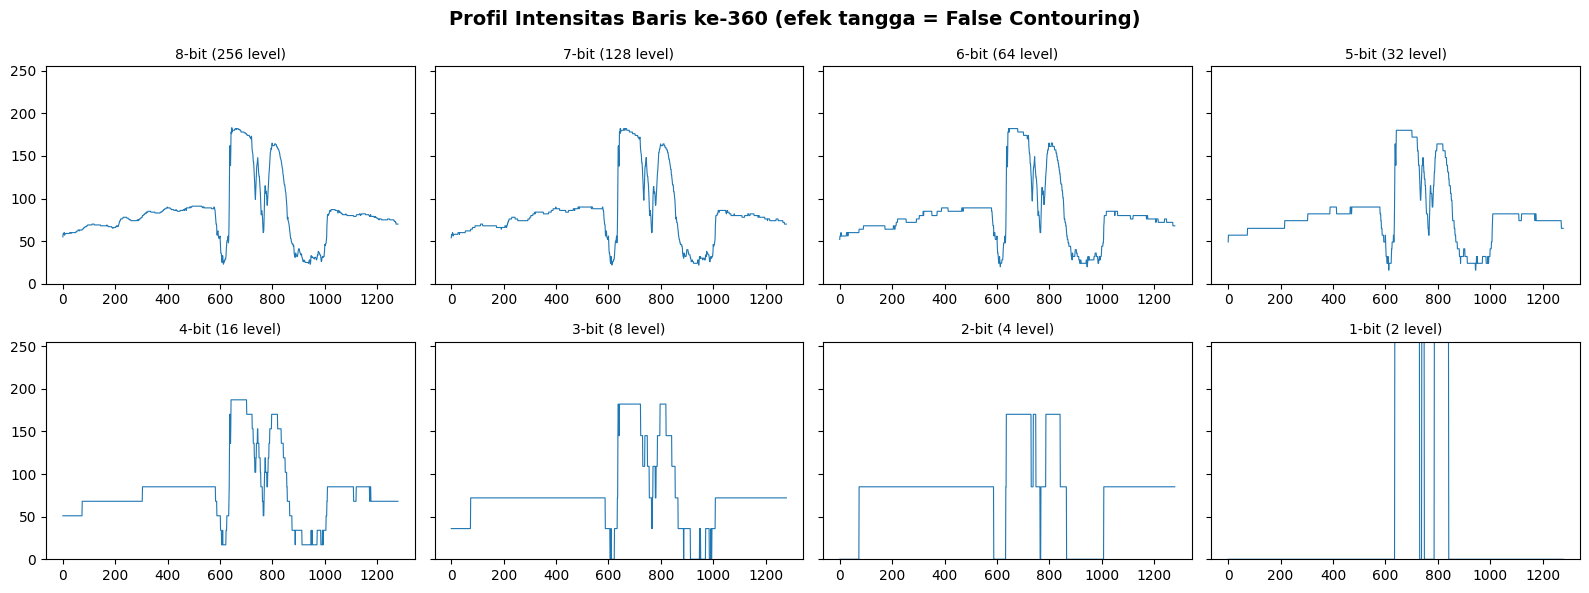

In [ ]:
citra = [q8, q7, q6, q5, q4, q3, q2, q1]
label = [8, 7, 6, 5, 4, 3, 2, 1]

# Bukti kuantitatif: seberapa besar lompatan antar level
print("Bit | Level | Jarak Antar Level (0-255) | Kontras per Step")
print("-" * 58)
for bits in label:
    levels = 2 ** bits
    step = 255 / (levels - 1)
    print(f"{bits:^3} | {levels:^5} | {step:^25.2f} | {step/255*100:5.2f} %")

# Bukti visual: profil intensitas satu baris menjadi gradasi halus berubah jadi tangga
baris = gray.shape[0] // 2   # ganti angka ini ke baris yang melewati area halus

fig, axs = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
fig.suptitle(f'Profil Intensitas Baris ke-{baris} (efek tangga = False Contouring)',
             fontsize=14, fontweight='bold')

for ax, img, bits in zip(axs.ravel(), citra, label):
    ax.plot(img[baris, :], linewidth=0.8)
    ax.set_title(f'{bits}-bit ({2**bits} level)', fontsize=10)
    ax.set_ylim(0, 255)

plt.tight_layout()
plt.show()

### 3. Perbandingan Kuantisasi Intensitas 8 bit ke 1 bit

Semua hasil kuantisasi tadi (q8 sampai q1) saya tampilkan dalam satu figure 2 x 4
biar bisa dibandingkan sekaligus.

Catatan waktu menampilkan: vmin=0 dan vmax=255 harus ditulis. Kalau tidak,
matplotlib otomatis menormalisasi ke rentang min-max tiap citra, jadi citra 1 bit
pun tetap terlihat normal dan perbandingannya jadi tidak adil.

Analisis hasil:

Dari 8 bit sampai 6 bit hampir tidak ada bedanya. Wajar, karena jarak antar
levelnya masih kecil (di 6 bit cuma 4), masih di bawah batas mata bisa
membedakannya.

Mulai 5 dan 4 bit baru kelihatan. Gradasi halus di latar belakang dan kulit pecah
jadi bidang-bidang datar bertingkat. Ini yang disebut kontur palsu, muncul karena
nilai-nilai yang berdekatan dipaksa dibulatkan ke level yang sama.

Di 3 dan 2 bit sudah seperti poster. Tekstur rambut dan bayangan di wajah hilang,
tinggal blok besar hitam, abu-abu, dan putih.

Di 1 bit tinggal siluet. Bentuk orangnya masih kebaca, tapi gradasinya hilang
total karena cuma tersisa dua nilai.

Kesimpulan:

Makin kecil bit, makin hemat penyimpanan tapi makin banyak informasi intensitas
yang hilang. Untuk citra ini 6 bit masih aman, di bawah 5 bit penurunannya sudah
jelas terlihat.

Grafik disimpan: hasil_praktikum_minggu_1.png


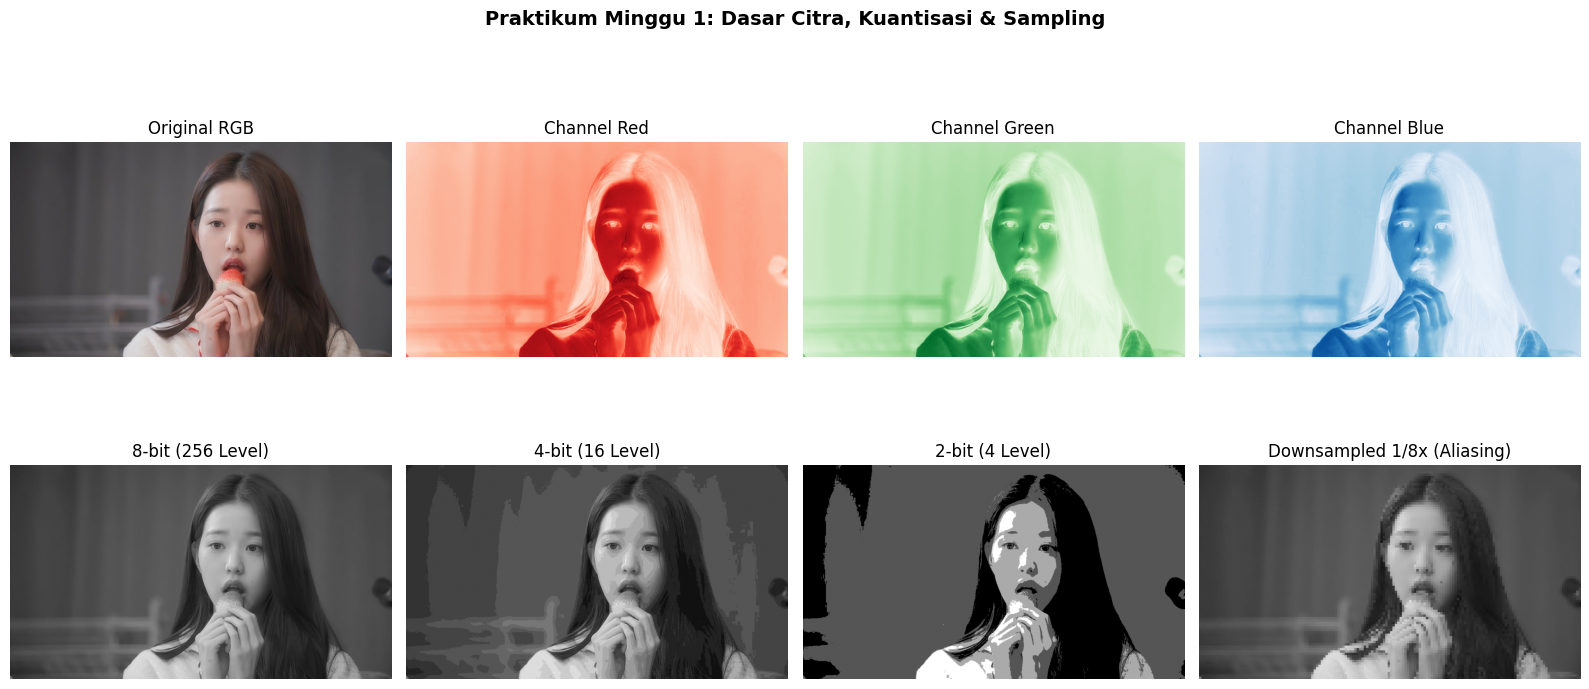

In [ ]:
# Visualisasi Matplotlib
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Praktikum Minggu 1: Dasar Citra, Kuantisasi & Sampling', fontsize=14, fontweight='bold')

axs[0, 0].imshow(img_rgb); axs[0, 0].set_title('Original RGB')
axs[0, 1].imshow(R, cmap='Reds', vmin=0, vmax=255); axs[0, 1].set_title('Channel Red')
axs[0, 2].imshow(G, cmap='Greens', vmin=0, vmax=255); axs[0, 2].set_title('Channel Green')
axs[0, 3].imshow(B, cmap='Blues', vmin=0, vmax=255); axs[0, 3].set_title('Channel Blue')

axs[1, 0].imshow(q8, cmap='gray', vmin=0, vmax=255); axs[1, 0].set_title('8-bit (256 Level)')
axs[1, 1].imshow(q4, cmap='gray', vmin=0, vmax=255); axs[1, 1].set_title('4-bit (16 Level)')
axs[1, 2].imshow(q2, cmap='gray', vmin=0, vmax=255); axs[1, 2].set_title('2-bit (4 Level)')
axs[1, 3].imshow(pixelated, cmap='gray', vmin=0, vmax=255); axs[1, 3].set_title('Downsampled 1/8x (Aliasing)')

for ax in axs.ravel(): ax.axis('off')
plt.tight_layout()
plt.savefig('hasil_praktikum_minggu_1.png', dpi=200)
print("Grafik disimpan: hasil_praktikum_minggu_1.png")
plt.show()

### Visualisasi Ringkasan

Cell ini cuma rekap. Semua hasil yang tadi dikerjakan terpisah saya kumpulkan
jadi satu figure 2 x 4 biar kelihatan utuh. Baris atas soal warna, baris bawah
soal kuantisasi dan sampling.

Di baris atas, citra dipecah jadi tiga channel R, G, dan B. Tiap channel isinya
satu angka per piksel, jadi sebenarnya sama saja dengan citra grayscale. Kulit
wajah paling terang di channel Red, cocok dengan rata-rata yang tadi dihitung
(R = 90.52, sedangkan G dan B cuma sekitar 81.8). Baju putih terang di ketiga
channel karena putih berarti R, G, B sama-sama tinggi. Rambut gelap di semua
channel karena hitam berarti ketiganya rendah.

Di baris bawah, tiga gambar pertama saya ambil dari hasil kuantisasi tadi
(8, 4, dan 2 bit). Kelihatan gradasinya makin lama makin pecah jadi bidang datar.
Gambar terakhir beda lagi, yang dikurangi bukan level warnanya tapi jumlah
pikselnya. Citra dikecilkan ke 1/8 lalu dibesarkan lagi, jadi satu piksel berubah
jadi kotak 8 x 8 dan detail halus seperti rambut jadi hilang.

Intinya baris bawah ini menunjukkan dua cara mengurangi informasi. Kuantisasi
memotong jumlah level intensitas, pikselnya tetap 1280 x 720. Downsampling
memotong jumlah piksel, level warnanya tetap 256. Efeknya juga beda, yang satu
kontur palsu, yang satu kotak-kotak.